# Gurobi Monotonic Approximation of Prices
version 1.1

In [1]:
# Let's start off by loading in the packages

# Let's load in the necessary packages
import pandas as pd
import datetime
import os
import timeit
import matplotlib.pyplot as plt
#import gurobipy as gp
#from gurobipy import GRB
import numpy as np
from scipy.optimize import curve_fit

### Loading in some data

In [2]:
# Loading in the data first.
# Let's load in the data here, and for now, let's make it just for four hours.

file_name = os.fsdecode("marco_data.csv")
workbook = pd.read_csv(file_name)
workbook = workbook.filter(items=["date", "he", "size","flexible","price"]) # Gets the columns that we need


workbook = workbook.query('date=="2024-04-10"') # Remove this to take out the filter for the day.

# Getting the columns we need.
merit_data = workbook.filter(items=["date", "he", "size","flexible","price","mkt_price","ail","datetime"]) # Gets the columns that we need
# I added "datetime" above so that it will be easier to filter out the merit data when looping through.

In [3]:
bids = merit_data.query('he==15')
bids=bids.sort_values('price').reset_index(drop = True)
# bids=bids.assign(merit=bids['size'].cumsum())
bids['merit'] = bids['size'].cumsum() # Old code is above

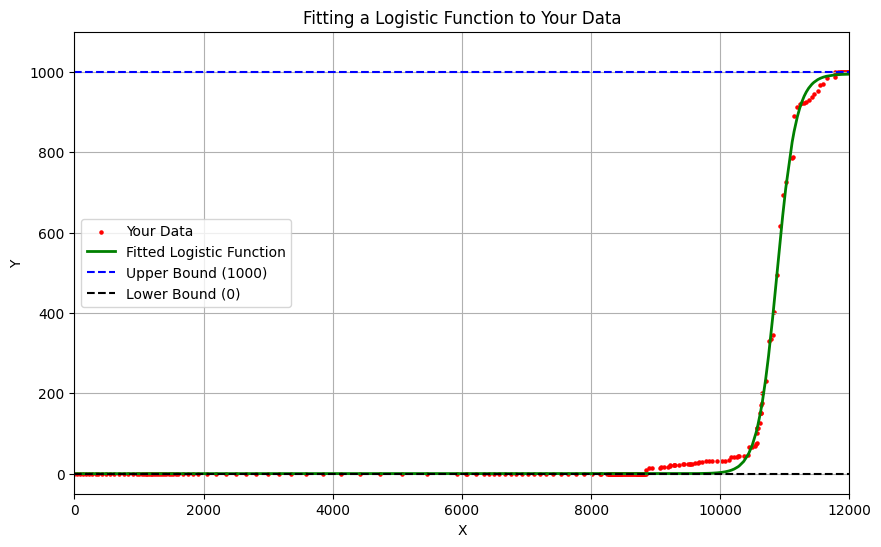

Fitted parameters:
L (max value): 994.8826864134588
k (steepness): 0.0067175192791510425
x0 (midpoint): 10878.112626555578


In [4]:

# Generate synthetic data for demonstration
# Replace this with your actual data
x = bids['merit']

# Generate y values according to your specifications
# Start at 0 for x in [0, 5000] and reach 1000 for x in [10000, 12000]
y = bids['price']


# Define the logistic function for fitting
def logistic_function(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

# Initial guesses for parameters: L, k, x0
initial_guesses = [1000, 0.0001, 7500]  # Adjusted values for wider x range

# Fit the logistic function to your data
popt, pcov = curve_fit(logistic_function, x, y, p0=initial_guesses)

# Extract fitted parameters
L_fit, k_fit, x0_fit = popt

# Generate fitted values
y_fitted = logistic_function(x, *popt)

# Plot your data and the fitted logistic function
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Your Data', color='red', s=5)
plt.plot(x, y_fitted, label='Fitted Logistic Function', color='green', linewidth=2)
plt.axhline(y=1000, color='blue', linestyle='--', label='Upper Bound (1000)')
plt.axhline(y=0, color='black', linestyle='--', label='Lower Bound (0)')
plt.xlim(0, 12000)  # Set x limits according to your domain
plt.ylim(-50, 1100)  # Adjust y-limits as necessary
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Fitting a Logistic Function to Your Data')
plt.legend()
plt.grid()
plt.show()

# Print the fitted parameters
print("Fitted parameters:")
print(f"L (max value): {L_fit}")
print(f"k (steepness): {k_fit}")
print(f"x0 (midpoint): {x0_fit}")

C:\Users\aleach\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


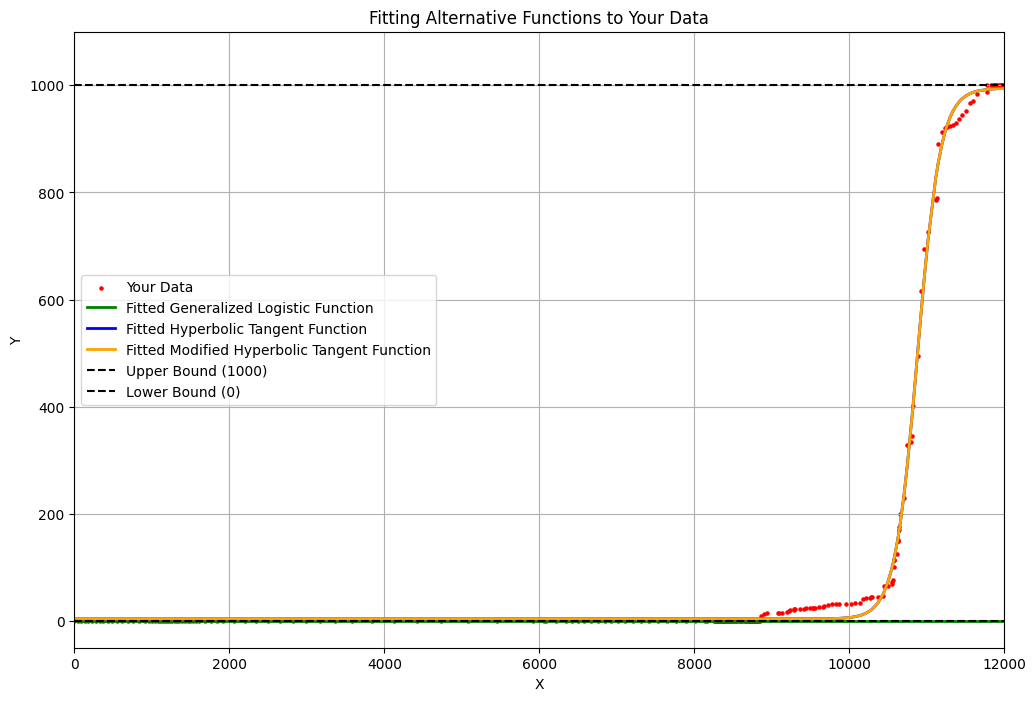

Fitted parameters for Generalized Logistic Function:
L (max value): 8443.052623727965
k (steepness): -0.00016419392079837757
x0 (midpoint): 174785.3393819931
b (curvature): -1.6419541571357432

Fitted parameters for Hyperbolic Tangent Function:
A (amplitude): 495.3622250319345
B (steepness): 0.003393086876744526
C (midpoint): 10879.530192179249
D (baseline): 499.1855323265348


In [5]:
# Define the generalized logistic function for fitting
def generalized_logistic(x, L, k, x0, b):
    return L / (1 + np.exp(-k * (x - x0))**b)

# Define the hyperbolic tangent function for fitting
def tanh_function(x, A, B, C, D):
    return A * np.tanh(B * (x - C)) + D

# Initial guesses for generalized logistic parameters
initial_guesses_logistic = [1000, 0.0001, 7500, 1]  # L, k, x0, b

# Fit the generalized logistic function to your data
popt_logistic, pcov_logistic = curve_fit(generalized_logistic, x, y, p0=initial_guesses_logistic)

# Fit the hyperbolic tangent function to your data
initial_guesses_tanh = [1000, 0.00001, 7500, 0]  # A, B, C, D
popt_tanh, pcov_tanh = curve_fit(tanh_function, x, y, p0=initial_guesses_tanh)

# Generate fitted values
y_fitted_logistic = generalized_logistic(x, *popt_logistic)
y_fitted_tanh = tanh_function(x, *popt_tanh)


def modified_tanh(x, A, k, x0, b):
    return A * np.tanh(k * (x - x0)) + b




# Set initial parameter guesses
initial_guesses = [1000, 0.001, 5000, 0]

# Fit the modified hyperbolic tangent function to your data
popt_mtanh, pcov_mtanh = curve_fit(modified_tanh, x, y, p0=initial_guesses)

# Extract fitted parameters
A_fit, k_fit, x0_fit, b_fit = popt_mtanh

# Generate fitted values
y_fitted_mtanh = modified_tanh(x, A_fit, k_fit, x0_fit, b_fit)

# Plot your data and the fitted functions
plt.figure(figsize=(12, 8))
plt.scatter(x, y, label='Your Data', color='red', s=5)
plt.plot(x, y_fitted_logistic, label='Fitted Generalized Logistic Function', color='green', linewidth=2)
plt.plot(x, y_fitted_tanh, label='Fitted Hyperbolic Tangent Function', color='blue', linewidth=2)
plt.plot(x, y_fitted_mtanh, label='Fitted Modified Hyperbolic Tangent Function', color='orange', linewidth=2)
plt.axhline(y=1000, color='black', linestyle='--', label='Upper Bound (1000)')
plt.axhline(y=0, color='black', linestyle='--', label='Lower Bound (0)')
plt.xlim(0, 12000)  # Set x limits according to your domain
plt.ylim(-50, 1100)  # Adjust y-limits as necessary
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Fitting Alternative Functions to Your Data')
plt.legend()
plt.grid()
plt.show()

# Print the fitted parameters
print("Fitted parameters for Generalized Logistic Function:")
print(f"L (max value): {popt_logistic[0]}")
print(f"k (steepness): {popt_logistic[1]}")
print(f"x0 (midpoint): {popt_logistic[2]}")
print(f"b (curvature): {popt_logistic[3]}")

print("\nFitted parameters for Hyperbolic Tangent Function:")
print(f"A (amplitude): {popt_tanh[0]}")
print(f"B (steepness): {popt_tanh[1]}")
print(f"C (midpoint): {popt_tanh[2]}")
print(f"D (baseline): {popt_tanh[3]}")

C:\Users\aleach\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


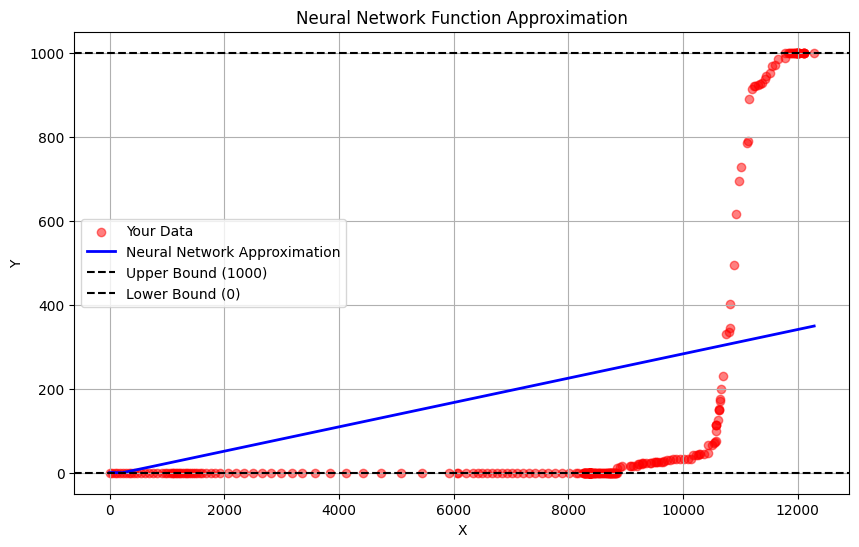

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# Sample x and y data (replace these with your actual data)
x = bids['merit']
x = x.to_numpy()


# Generate y values according to your specifications
y = bids['price']
y = y.to_numpy()


# Reshape the data
x = x.reshape(-1, 1)  # Reshape x to be a 2D array

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create the neural network model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(1,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)  # Output layer
])


# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(x_train, y_train, epochs=500, batch_size=20, verbose=0)

# Predict values using the trained model
y_pred = model.predict(x)

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', label='Your Data', alpha=0.5)
plt.plot(x, y_pred, color='blue', label='Neural Network Approximation', linewidth=2)
plt.axhline(y=1000, color='black', linestyle='--', label='Upper Bound (1000)')
plt.axhline(y=0, color='black', linestyle='--', label='Lower Bound (0)')
plt.title('Neural Network Function Approximation')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid()
plt.show()

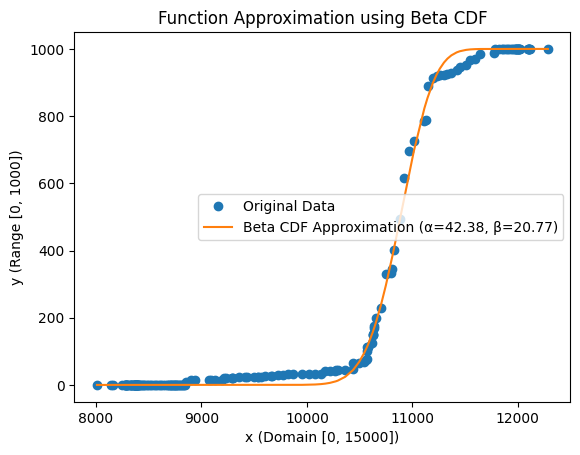

In [19]:
from scipy.stats import beta

# Example data (you would use your actual data here)
data = np.random.beta(2, 5, size=1000)  # Example data from a Beta distribution

# Fit the Beta distribution to the data
alpha, beta_param, loc, scale = beta.fit(data, floc=0, fscale=1)  # Force it to be in [0, 1]

bids_temp=bids.query('merit>8000')
x = bids_temp['merit']
x = x.to_numpy()
y = bids_temp['price']

new_x = np.arange(x[-1] + 50, x[-1] + 50 * 51, 50)  # Generate 50 new x values, increasing by 50
new_y = np.full(50, 1000)  # Generate 50 new y values, all set to 1000

# Normalize the domain (x) to [0, 1]
x_normalized = (x - np.min(x)) / (np.max(x) - np.min(x))

# Normalize the range (y) to [0, 1]
y_normalized = (y - np.min(y)) / (np.max(y) - np.min(y))

# Function to approximate with the Beta CDF
def beta_cdf(x, alpha, beta_param):
    return beta.cdf(x, alpha, beta_param)

# Fit the Beta CDF to the normalized data
popt, _ = curve_fit(beta_cdf, x_normalized, y_normalized)

# Retrieve fitted alpha and beta parameters
alpha_fitted, beta_fitted = popt

# Approximate y using the fitted Beta CDF
y_approx_normalized = beta.cdf(x_normalized, alpha_fitted, beta_fitted)

# Rescale the approximated y back to original range [0, 1000]
y_approx = y_approx_normalized * (1000 - 0) + 0  # Range [0, 1000]

# Plot the original data and the approximation
plt.plot(x, y, 'o', label='Original Data')
plt.plot(x, y_approx, '-', label=f'Beta CDF Approximation (α={alpha_fitted:.2f}, β={beta_fitted:.2f})')
plt.title("Function Approximation using Beta CDF")
plt.xlabel('x (Domain [0, 15000])')
plt.ylabel('y (Range [0, 1000])')
plt.legend()
plt.show()